In [1]:
# Importing libraries
import numpy as np
from scipy.sparse import diags, kronsum
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt
plt.style.use("bmh")

import plotly.graph_objects as go

In [2]:
# Solution function
def solution(N = 50, num_eigenvalues = 30, potential_function = None):
    
    # Grid parameters
    delta = 1.0 / (N - 1)  # Grid spacing
    
    # 1D Laplacian matrix L (M x M)
    main_diag = - 2 * np.ones(N - 2)
    off_diag = np.ones(N - 2 - 1)
    
    L = diags([off_diag, main_diag, off_diag], 
              [- 1, 0, 1], 
              shape = (N - 2, N - 2), 
              format = 'csr')
    
    # 3D Laplacian matrix
    L3 = kronsum(kronsum(L, L), L) / 2
    
    # Hamiltonian without potential: H = -L3 / delta ^2
    H = - L3 / (delta ** 2)
    
    # Add potential if provided
    if potential_function is not None:

        x = np.linspace(delta, 1 - delta, N - 2)
        y = np.linspace(delta, 1 - delta, N - 2)
        z = np.linspace(delta, 1 - delta, N - 2)
        
        X, Y, Z = np.meshgrid(x, y, z, indexing = 'ij')
        
        V_values = potential_function(X, Y, Z)
        
        # Flatten to 1D and create diagonal matrix
        V_diag = diags(V_values.flatten() / 2, 0, format = 'csr')
        
        # Hamiltonian with a potential: H = - L3 / delta ^ 2 + diag(V)
        H = H + V_diag
    
    # Compute some eigenvalues
    E_prime, psi_prime = eigsh(H, k = num_eigenvalues, which = 'SA')
    
    # Reshape eigenfunctions to 3D and normalize
    psi_3D_prime = []
    
    for i in range(num_eigenvalues):
        vec = psi_prime[:, i].reshape(N - 2, N - 2, N - 2)
        
        # Calculate normalization constant
        norm_sq = np.sum(np.abs(vec) ** 2) * (delta ** 3)
        norm = np.sqrt(norm_sq)
        vec = vec / norm
        psi_3D_prime.append(vec)
    
    psi_3D_prime = np.array(psi_3D_prime)
    
    return (E_prime, psi_3D_prime)

###########################

# Interactive plot function
def plot(psi_3d, N = 50):

    delta = 1.0 / (N - 1)
    
    # Coordinates
    x = np.linspace(delta, 1 - delta, N - 2)
    y = np.linspace(delta, 1 - delta, N - 2)
    z = np.linspace(delta, 1 - delta, N - 2)
    X, Y, Z = np.meshgrid(x, y, z, indexing = 'ij')
    
    prob_density = np.abs(psi_3d) ** 2
    
    # Flatten and sort probabilities
    flat_probs = prob_density.flatten()
    sorted_probs = np.sort(flat_probs)[::-1]  # Descending
    
    # Cumulative probability
    cumulative_prob = np.cumsum(sorted_probs) * (delta ** 3)
    
    # Find threshold for 90% confidence
    confidence = 0.9
    idx = np.searchsorted(cumulative_prob, confidence)
    if idx >= len(sorted_probs):
        threshold = sorted_probs[-1]
    else:
        threshold = sorted_probs[idx]
    
    # Create isosurface
    fig = go.Figure(data = go.Isosurface(
        x = X.flatten(),
        y = Y.flatten(),
        z = Z.flatten(),
        value = prob_density.flatten(),
        isomin = threshold,
        isomax = prob_density.max(),
        opacity = 0.5,
        surface_count = 1,
        colorscale = [[0, 'blue'], [1, 'blue']],
        showscale = False,
        caps = dict(x_show = False, y_show = False, z_show = False)
    ))
    
    fig.update_layout(
        title = '90% Probability Region',
        scene = dict(
            xaxis_title = 'x / L',
            yaxis_title = 'y / L',
            zaxis_title = 'z / L',
            aspectmode = 'cube'
        ),

        width = 600,
        height = 500
    )
    
    fig.show()
    return None

######################

# Energy plot function
def eplot(E_prime):
    
    plt.eventplot(E_prime, orientation = 'vertical', linewidth = 0.5, color = 'green')
    plt.title("Energy spectrum", fontsize = 16)
    plt.ylabel(r"$E / \frac{\hbar ^ 2}{m L ^ 2}$", fontsize = 16)
    plt.show()
    
    return None

In [3]:
# Free particle within the box
E_prime, psi_prime = solution()
E_prime

array([ 14.79933602,  29.57840082,  29.57840082,  29.57840082,
        44.35746563,  44.35746563,  44.35746563,  54.14268808,
        54.14268808,  54.14268808,  59.13653043,  68.92175288,
        68.92175288,  68.92175288,  68.92175288,  68.92175288,
        68.92175288,  83.70081769,  83.70081769,  83.70081769,
        88.39125786,  88.39125786,  88.39125786,  93.48604014,
        93.48604014,  93.48604014, 103.17032266, 103.17032266,
       103.17032266, 103.17032266])

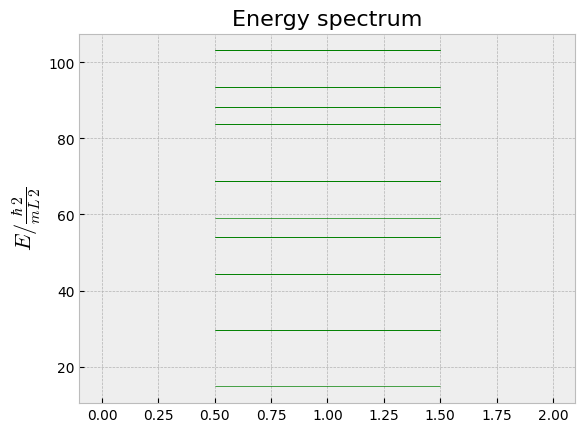

In [4]:
eplot(E_prime)

In [5]:
# for j in range(0, 11, 1):
    # plot(psi_prime[j])

In [6]:
def harmonic_potential_prime(x, y, z):
    x0, y0, z0 = (0.5, 0.5, 0.5)
    V0_prime = 400.0

    return V0_prime * ((x - x0) ** 2 + (y - y0) ** 2 + (z - z0) ** 2)

In [7]:
# Harmonic potential solution
E_prime, psi_prime = solution(potential_function = harmonic_potential_prime)
E_prime

array([ 30.90383579,  53.13845844,  53.13845844,  53.13845844,
        75.3730811 ,  75.3730811 ,  75.3730811 ,  80.40948507,
        80.40948507,  80.40948507,  97.60770375, 102.64410772,
       102.64410772, 102.64410772, 102.64410772, 102.64410772,
       102.64410772, 115.44968686, 115.44968686, 115.44968686,
       124.87873038, 124.87873038, 124.87873038, 129.91513435,
       129.91513435, 129.91513435, 137.68430952, 137.68430952,
       137.68430952, 137.68430952])

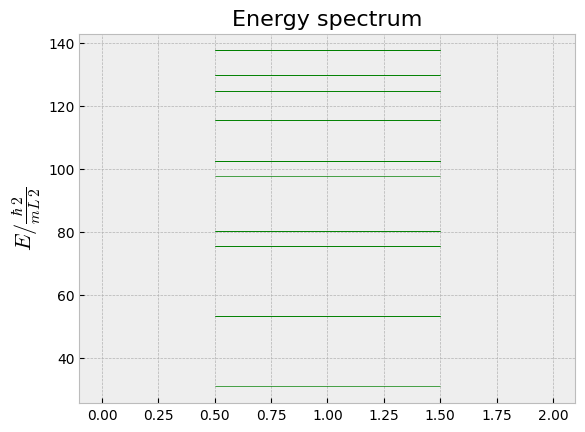

In [8]:
eplot(E_prime)

In [9]:
# for j in range(0, 11, 1):
    # plot(psi_prime[j])

In [10]:
def central_potential_prime(x, y, z):
    x0, y0, z0 = (0.5, 0.5, 0.5)
    V0_prime = 30.0

    return - V0_prime / np.sqrt((x - x0) ** 2 + (y - y0) ** 2 + (z - z0) ** 2 + 1e-15)

In [11]:
# Hydrogen-like solution
E_prime, psi_prime = solution(potential_function = central_potential_prime)
E_prime

array([-110.06106987,  -25.00414194,  -25.00414194,  -25.00414194,
        -21.50121832,    2.61975323,    2.61975323,    2.61975323,
          8.30582211,    8.30582211,   19.72465556,   19.72465556,
         19.72465556,   23.29339404,   30.27236896,   30.27236896,
         30.27236896,   31.65290748,   38.5044692 ,   38.5044692 ,
         38.5044692 ,   47.1435377 ,   47.1435377 ,   47.1435377 ,
         54.64857179,   54.64857179,   58.83973125,   58.83973125,
         58.83973125,   65.52703144])

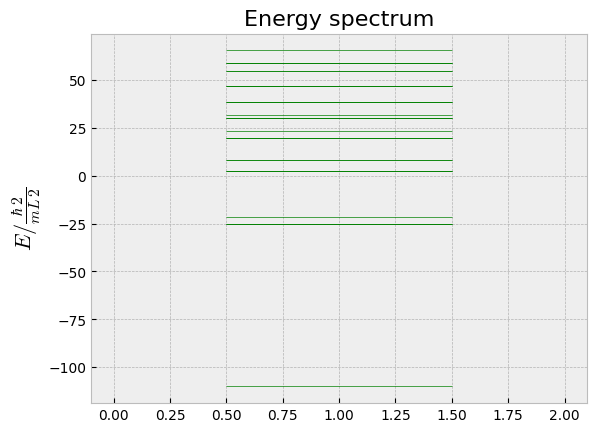

In [12]:
eplot(E_prime)

In [13]:
# for j in range(0, 11, 1):
    # plot(psi_prime[j])